In [13]:
# CELL 1 – Importing libraries and configuring global style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime
import re

# Configuring style and palette
sns.set_theme(style="darkgrid", palette="rocket")
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [14]:
# CELL 2 – Loading dataset
DATA_PATH = "../data/raw/nyc_traffic_raw.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Data loaded successfully. Rows: {df.shape[0]}, Columns: {df.shape[1]}")
except FileNotFoundError:
    print("Raw data not found. Using demo sample instead")

df.head()

Data loaded successfully. Rows: 42756, Columns: 31


,ID,SegmentID,Roadway Name,From,To,Direction,Date,12:00-1:00 AM,1:00-2:00AM,2:00-3:00AM,3:00-4:00AM,4:00-5:00AM,5:00-6:00AM,6:00-7:00AM,7:00-8:00AM,8:00-9:00AM,9:00-10:00AM,10:00-11:00AM,11:00-12:00PM,12:00-1:00PM,1:00-2:00PM,2:00-3:00PM,3:00-4:00PM,4:00-5:00PM,5:00-6:00PM,6:00-7:00PM,7:00-8:00PM,8:00-9:00PM,9:00-10:00PM,10:00-11:00PM,11:00-12:00AM
0,1,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/09/2012,20,10,11,14,13,20,34,66,100,52,68,85,85,94,104,105,147,120,91,83,74,49,42,42
1,2,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/10/2012,21,16,8,6,13,13,31,70,67,45,57,67,73,95,102,98,133,131,95,73,70,63,42,35
2,3,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/11/2012,27,14,6,5,12,16,34,75,69,71,67,70,90,89,115,115,130,143,106,89,68,64,56,43
3,4,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/12/2012,22,7,7,8,11,12,33,75,89,66,70,60,105,103,71,127,122,144,122,76,64,58,64,43
4,5,15540,BEACH STREET,UNION PLACE,VAN DUZER STREET,NB,01/13/2012,31,17,7,5,13,28,29,68,84,64,83,89,88,113,113,126,133,135,102,106,58,58,55,54


In [15]:
# CELL 3 – Basic info and missing-value summary
print("=" * 50)
print("Dataset Info:")
print("=" * 50)
df.info()

print("=" * 50)
print("Missing Values")
print("=" * 50)
print(df.isna().sum())

print("=" * 50)
print("Duplicate Records")
print("=" * 50)
print(df.duplicated().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42756 entries, 0 to 42755
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             42756 non-null  int64 
 1   SegmentID      42756 non-null  int64 
 2   Roadway Name   42756 non-null  object
 3   From           42756 non-null  object
 4   To             42756 non-null  object
 5   Direction      42756 non-null  object
 6   Date           42756 non-null  object
 7   12:00-1:00 AM  42752 non-null  object
 8   1:00-2:00AM    42752 non-null  object
 9   2:00-3:00AM    42752 non-null  object
 10  3:00-4:00AM    42752 non-null  object
 11  4:00-5:00AM    42752 non-null  object
 12  5:00-6:00AM    42752 non-null  object
 13  6:00-7:00AM    42752 non-null  object
 14  7:00-8:00AM    42752 non-null  object
 15  8:00-9:00AM    42752 non-null  object
 16  9:00-10:00AM   42752 non-null  object
 17  10:00-11:00AM  42753 non-null  object
 18  11:00-12:00P

In [16]:
# CELL 4 – Reshaping wide hourly columns and creating temporal features
df.columns = (df.columns
                .str.replace("\xa0"," ", regex=False)
                .str.replace("–","-", regex=False)
                .str.replace("—","-", regex=False)
                .str.strip())

date_col = "Date"
hour_columns = [c for c in df.columns if (":" in c and ("AM" in c or "PM" in c))]
if not hour_columns:
    raise ValueError(f"No hourly columns detected. Columns available: {list(df.columns)}")

print(f"Detected {len(hour_columns)} hourly columns: {hour_columns[:5]}...")

df_long = df.melt(
    id_vars=[date_col, "Roadway Name", "Direction"],
    value_vars=hour_columns,
    var_name="hour_range",
    value_name="vehicles_counted"
)

df_long[date_col] = pd.to_datetime(df_long[date_col], errors="coerce")

def parse_hour(label):
    if not isinstance(label, str):
        return np.nan
    s = (label.replace("–","-").replace("—","-"))
    s = re.sub(r"\s+", " ", s).strip().upper()
    m = re.match(r"(\d{1,2}):?(\d{0,2})? ?(AM|PM)", s)
    if not m:
        alt = re.search(r"(AM|PM)", s)
        if alt:
            left = s.split("-")[0].strip() + " " + alt.group(1)
            m = re.match(r"(\d{1,2}):?(\d{0,2})? ?(AM|PM)", left)
        if not m:
            return np.nan
    hh, mm, period = m.groups()
    hh = int(hh); mm = int(mm) if mm else 0
    if period == "PM" and hh != 12:
        hh += 12
    if period == "AM" and hh == 12:
        hh = 0
    return hh

df_long["hour"] = df_long["hour_range"].apply(parse_hour)
df_long["vehicles_counted"] = pd.to_numeric(df_long["vehicles_counted"], errors="coerce")
df_long["datetime"] = df_long[date_col] + pd.to_timedelta(df_long["hour"], unit="h")
df_long["weekday"] = df_long["datetime"].dt.day_name()
df_long["month"] = df_long["datetime"].dt.month_name()
df_long["is_weekend"] = df_long["weekday"].isin(["Saturday","Sunday"])

df = df_long.rename(columns={"Roadway Name":"roadway_name","Direction":"direction"})
print(f"Reshaped successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Detected 24 hourly columns: ['12:00-1:00 AM', '1:00-2:00AM', '2:00-3:00AM', '3:00-4:00AM', '4:00-5:00AM']...
Reshaped successfully: 1,026,144 rows × 10 columns


,Date,roadway_name,direction,hour_range,vehicles_counted,hour,datetime,weekday,month,is_weekend
0,2012-01-09,BEACH STREET,NB,12:00-1:00 AM,20.0,0,2012-01-09,Monday,January,False
1,2012-01-10,BEACH STREET,NB,12:00-1:00 AM,21.0,0,2012-01-10,Tuesday,January,False
2,2012-01-11,BEACH STREET,NB,12:00-1:00 AM,27.0,0,2012-01-11,Wednesday,January,False
3,2012-01-12,BEACH STREET,NB,12:00-1:00 AM,22.0,0,2012-01-12,Thursday,January,False
4,2012-01-13,BEACH STREET,NB,12:00-1:00 AM,31.0,0,2012-01-13,Friday,January,False


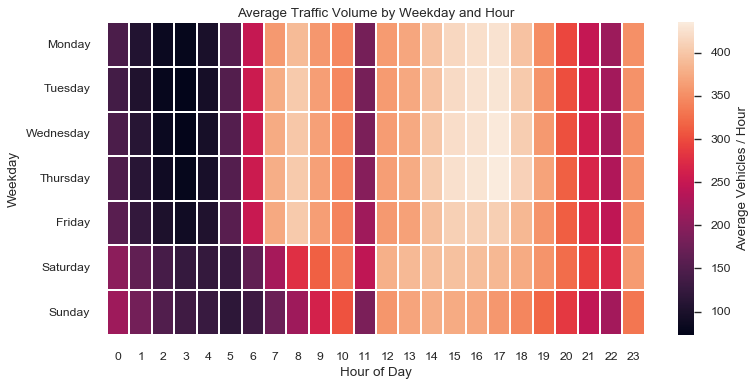

In [18]:
# CELL 4B – Validating weekday × hour pattern with heatmap
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = (df.groupby(["weekday","hour"])["vehicles_counted"]
           .mean()
           .unstack()
           .reindex(weekday_order))

plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap="rocket", linewidths=0.3, cbar_kws={"label":"Average Vehicles / Hour"})
plt.title("Average Traffic Volume by Weekday and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()


In [19]:
# CELL 5 – Generating descriptive statistics
num_summary = df[["vehicles_counted","hour"]].describe().T
cat_summary = df[["roadway_name","direction","weekday","month","is_weekend"]].describe().T

display(num_summary)
display(cat_summary)

,count,mean,std,min,25%,50%,75%,max
vehicles_counted,925721.0,274.357911,228.845346,0.0,89.00,216.0,399.00,999.0
hour,1026144.0,11.500000,6.922190,0.0,5.75,11.5,17.25,23.0


,count,unique,top,freq
roadway_name,1026144,1276,BROADWAY,11352
direction,1026144,14,NB,293616
weekday,1026144,7,Saturday,211752
month,1026144,9,October,486264
is_weekend,1026144,2,False,602736


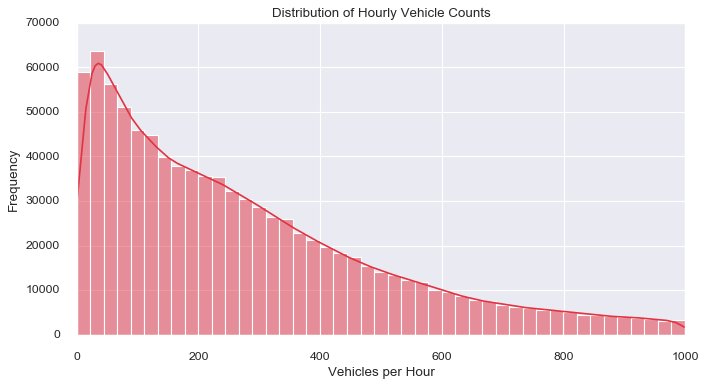

In [21]:
# CELL 6 – Plotting overall distribution of hourly vehicle counts
plt.figure(figsize=(9,5))
sns.histplot(df["vehicles_counted"], bins=45, kde=True, color=sns.color_palette("rocket")[3])
plt.title("Distribution of Hourly Vehicle Counts")
plt.xlabel("Vehicles per Hour")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

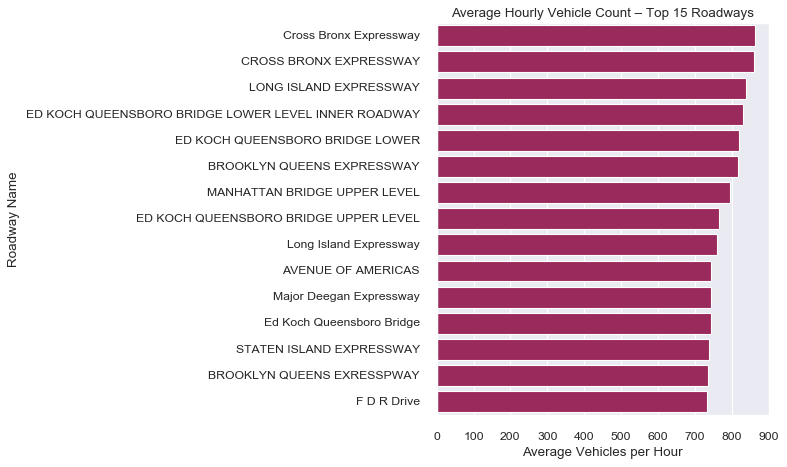

,average_vehicles_per_hour
roadway_name,
Cross Bronx Expressway,861.24
CROSS BRONX EXPRESSWAY,860.25
LONG ISLAND EXPRESSWAY,836.51
ED KOCH QUEENSBORO BRIDGE LOWER LEVEL INNER ROADWAY,830.43
ED KOCH QUEENSBORO BRIDGE LOWER,819.71
BROOKLYN QUEENS EXPRESSWAY,817.24
MANHATTAN BRIDGE UPPER LEVEL,795.31
ED KOCH QUEENSBORO BRIDGE UPPER LEVEL,765.96
Long Island Expressway,758.62


In [26]:
# CELL 7 – Plotting top 15 busiest roadways by mean traffic
top_roads = (df.groupby("roadway_name")["vehicles_counted"]
               .mean()
               .sort_values(ascending=False)
               .head(15)
               .round(2))

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(x=top_roads.values, y=top_roads.index, color=sns.color_palette("rocket")[2], ax=ax)
ax.set_title("Average Hourly Vehicle Count – Top 15 Roadways")
ax.set_xlabel("Average Vehicles per Hour")
ax.set_ylabel("Roadway Name")
plt.tight_layout()
plt.show()

top_roads.to_frame("average_vehicles_per_hour")

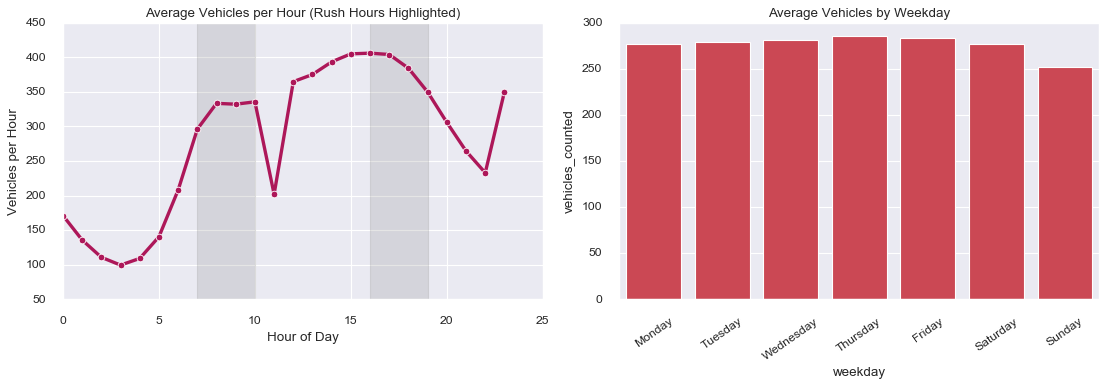

In [28]:
# CELL 8 – Visualizing temporal patterns
hourly = df.groupby("hour")["vehicles_counted"].mean().reset_index()
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_mean = (df.groupby("weekday")["vehicles_counted"]
                  .mean()
                  .reindex(weekday_order)
                  .reset_index())

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,5))

sns.lineplot(data=hourly, x="hour", y="vehicles_counted",
             color=sns.color_palette("rocket")[2], linewidth=3, marker="o", ax=ax1)
ax1.axvspan(7,10, color="gray", alpha=0.2)
ax1.axvspan(16,19, color="gray", alpha=0.2)
ax1.set_title("Average Vehicles per Hour (Rush Hours Highlighted)")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Vehicles per Hour")

sns.barplot(data=weekday_mean, x="weekday", y="vehicles_counted",
            color=sns.color_palette("rocket")[3], ax=ax2)
ax2.set_title("Average Vehicles by Weekday")
ax2.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

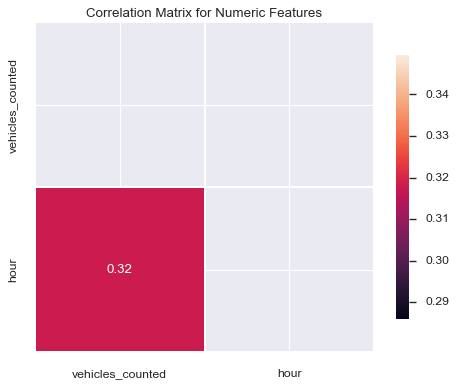

In [30]:
# CELL 9 – Computing correlation heatmap
corr = df[["vehicles_counted","hour"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(6,5))
sns.heatmap(corr, mask=mask, cmap="rocket", annot=True, fmt=".2f",
            linewidths=0.4, cbar_kws={"shrink":0.8})
plt.title("Correlation Matrix for Numeric Features")
plt.tight_layout()
plt.show()


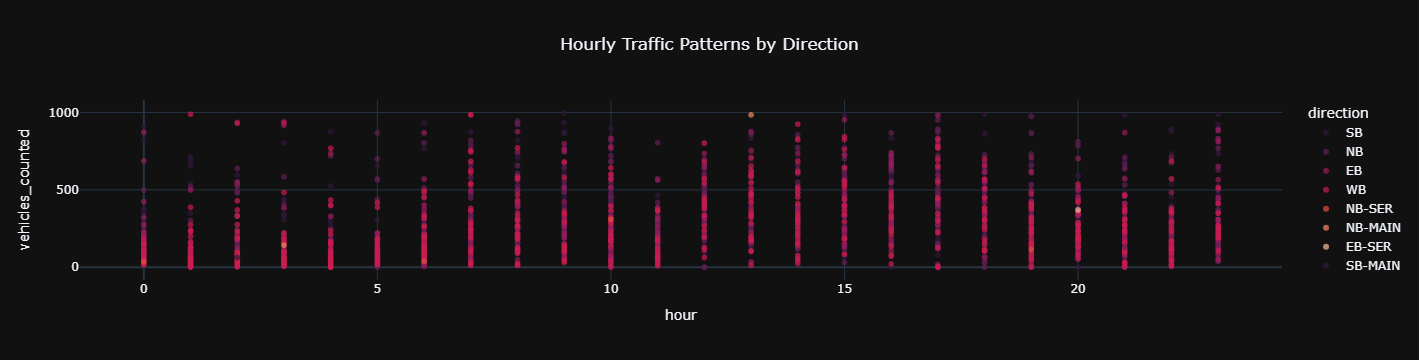

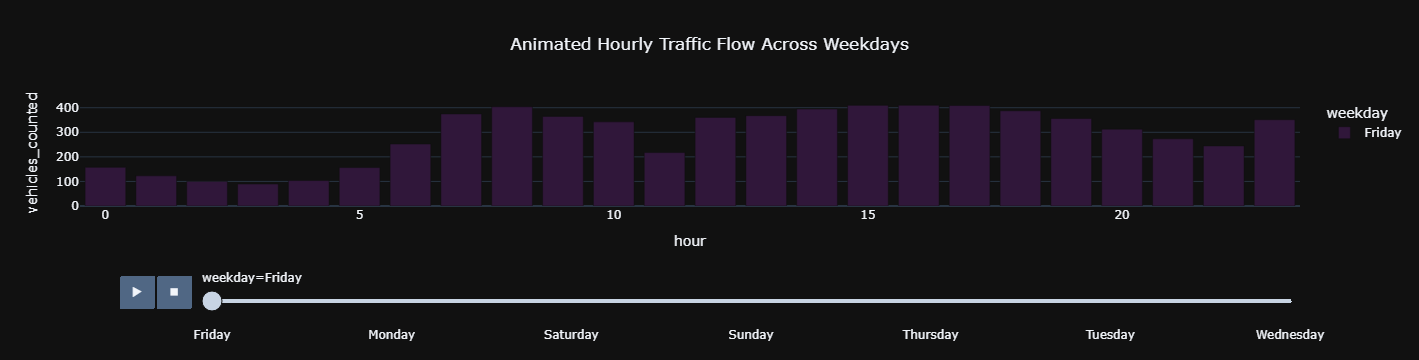

In [32]:
# CELL 10 – Creating interactive scatter and animated bars
import seaborn as sns
rocket_colors = sns.color_palette("rocket", 7).as_hex()

sample_n = min(2500, len(df))
fig1 = px.scatter(
    df.sample(sample_n),
    x="hour", y="vehicles_counted", color="direction",
    color_discrete_sequence=rocket_colors,
    opacity=0.7, template="plotly_dark",
    title="Hourly Traffic Patterns by Direction"
)
fig1.update_layout(title_x=0.5)
fig1.show()

agg = df.groupby(["weekday","hour"], as_index=False)["vehicles_counted"].mean()
fig2 = px.bar(
    agg, x="hour", y="vehicles_counted", color="weekday",
    animation_frame="weekday",
    color_discrete_sequence=rocket_colors,
    template="plotly_dark",
    title="Animated Hourly Traffic Flow Across Weekdays"
)
fig2.update_layout(title_x=0.5)
fig2.show()

In [33]:
# CELL 11 – Detecting anomalies using z-score
z = (df["vehicles_counted"] - df["vehicles_counted"].mean()) / df["vehicles_counted"].std()
outliers = df[np.abs(z) > 3]
print(f"Potential outliers detected: {len(outliers)}")

Potential outliers detected: 5617


In [34]:
# CELL 12 – Summarizing preliminary observations
observations = [
    "Observed clear morning and evening rush-hour peaks across weekdays.",
    "Noticed weekend profiles showing flatter intensity distribution.",
    "Detected mild right-skew in hourly counts indicating occasional extreme volumes.",
    "Found no concerning correlation among available numeric features.",
]
print("Preliminary observations:")
for i, s in enumerate(observations, 1):
    print(f"{i}. {s}")


Preliminary observations:
1. Observed clear morning and evening rush-hour peaks across weekdays.
2. Noticed weekend profiles showing flatter intensity distribution.
3. Detected mild right-skew in hourly counts indicating occasional extreme volumes.
4. Found no concerning correlation among available numeric features.


In [35]:
# CELL 13 – Exporting exploratory snapshot for preprocessing
EXPORT_PATH = "../data/processed/nyc_traffic_exploratory.csv"
df.to_csv(EXPORT_PATH, index=False)
print(f"Exploratory snapshot saved to {EXPORT_PATH}")

Exploratory snapshot saved to ../data/processed/nyc_traffic_exploratory.csv


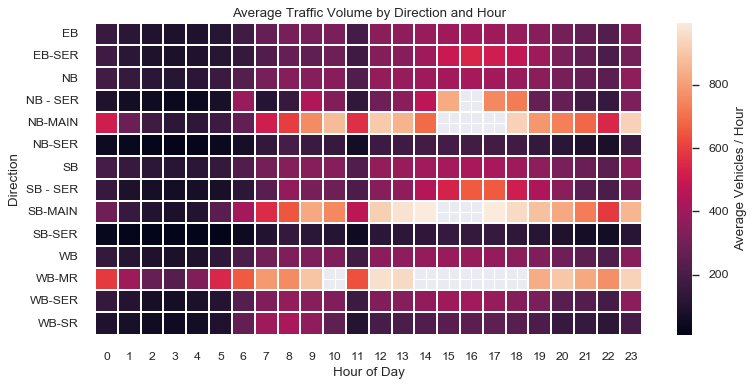

In [36]:
# CELL 14 – direction × hour heatmap
pivot2 = (df.groupby(["direction","hour"])["vehicles_counted"]
            .mean()
            .unstack())

plt.figure(figsize=(10,5))
sns.heatmap(pivot2, cmap="rocket", linewidths=0.3, cbar_kws={'label': 'Average Vehicles / Hour'})
plt.title("Average Traffic Volume by Direction and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Direction")
plt.tight_layout()
plt.show()

In [38]:
# CELL 15 – Quantifying variability and weekend effect
hourly_std = df.groupby("hour")["vehicles_counted"].std().mean()
avg_weekday = df.loc[~df["is_weekend"], "vehicles_counted"].mean()
avg_weekend = df.loc[df["is_weekend"], "vehicles_counted"].mean()
delta = avg_weekday - avg_weekend

print("Quantitative insights:")
print(f"- Average hourly variability: {hourly_std:.2f} vehicles/hour")
print(f"- Weekday vs Weekend difference: {delta:.1f} vehicles/hour "
      f"({avg_weekday:.1f} weekday vs {avg_weekend:.1f} weekend)")

Quantitative insights:
- Average hourly variability: 202.46 vehicles/hour
- Weekday vs Weekend difference: 16.9 vehicles/hour (281.3 weekday vs 264.5 weekend)
